# 1. Physics of Vibration

## a) Two Mass System

When I change the masses to be unequal (e.g., $m_1 = 1.0$ and $m_2 = 2.0$), the symmetry of the system is broken. In the high-frequency "out-of-phase" mode, I noticed that the heavier mass has a smaller amplitude than the lighter one. This makes sense physically because the heavier mass has more inertia, making it more resistant to the rapid changes in motion caused by the springs.

When I set the masses back to 1.0 and make the middle spring $k_2$ very small, the coupling between the two masses becomes weak. In this case, the frequencies of the two modes become almost identical. If I were to start one mass moving, it would take a long time for the energy to transfer to the other mass, creating a slow "beating" effect.

Finally, if I double all the spring constants $k$, the frequencies increase by a factor of $\sqrt{2} \approx 1.41$. This matches the theoretical expectation that $\omega = \sqrt{k/m}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def solve_vibration(n, m_vals, k_vals):
    M = np.diag(m_vals)
    K = np.zeros((n, n))
    for i in range(n):
        K[i, i] += k_vals[i] + k_vals[i+1]
        if i > 0: K[i, i-1] = -k_vals[i]
        if i < n-1: K[i, i+1] = -k_vals[i+1]
    evals, evecs = eigh(K, M)
    return np.sqrt(np.abs(evals)), evecs

# Case 1: Different Masses (m1=1, m2=2)
freqs_diff, evecs_diff = solve_vibration(2, [1.0, 2.0], [1.0, 1.0, 1.0])
print(f"Frequencies (m1=1, m2=2): {freqs_diff}")

# Case 2: Small k2 (k2=0.1)
freqs_weak, evecs_weak = solve_vibration(2, [1.0, 1.0], [1.0, 0.1, 1.0])
print(f"Frequencies (small k2): {freqs_weak}")

Frequencies (m1=1, m2=2): [0.79622522 1.538189  ]
Frequencies (small k2): [1.         1.09544512]


## b) Extending to N Masses

For the first four modes, the number of zero crossings (nodes) increases sequentially: Mode 1 has 0 nodes, Mode 2 has 1 node, Mode 3 has 2 nodes, and Mode 4 has 3 nodes. Following this pattern ($n-1$ nodes for the $n$-th mode), I expect the 10th mode to have 9 nodes.

Looking at the 10th mode in the plot below, we can see that the masses move in a zigzag pattern. Adjacent masses move in opposite directions (anti-phase), which is the characteristic of high-energy, high-frequency modes in a lattice or chain.

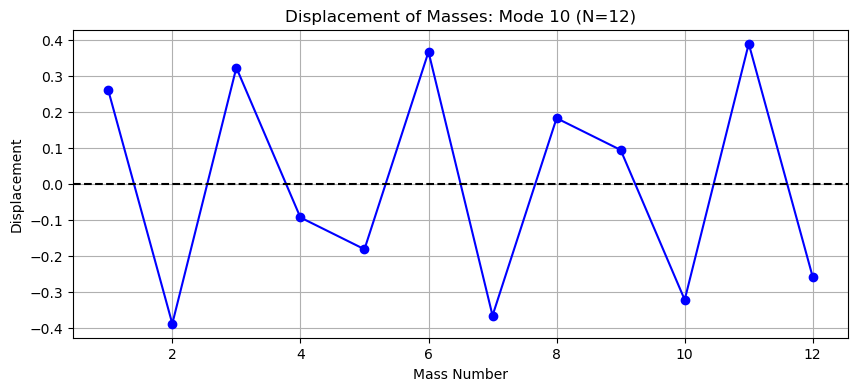

In [2]:
N = 12
m_list = [1.0] * N
k_list = [1.0] * (N + 1)
freqs_n, evecs_n = solve_vibration(N, m_list, k_list)

plt.figure(figsize=(10, 4))
plt.plot(range(1, N+1), evecs_n[:, 9], 'bo-', label='10th Mode')
plt.axhline(0, color='black', linestyle='--')
plt.title("Displacement of Masses: Mode 10 (N=12)")
plt.xlabel("Mass Number")
plt.ylabel("Displacement")
plt.grid(True)
plt.show()

## c) Array Indexing

When I check evecs.shape, it returns (12, 12). In this matrix, the columns represent the modes and the rows represent the masses.

Therefore, evecs[0] gives me the displacement of the first Mass across all modes.

If I want to find the displacement of Mass #3 during Mode #5, I would index the array as evecs[2, 4] (using 0-based indexing).

# 2. Static Systems: Ax=b

## a) Kirchhoff’s Loop Rule

The loop equations were converted into a coefficient matrix $A$ and a source vector $b$. Solving $Ax=b$ gives us the current in each of the three loops.

In [3]:
# Kirchhoff's Equations
A_k = np.array([[10, -2, 0], 
                [-2, 8, -4], 
                [0, -4, 6]])
b_k = np.array([12, 0, -5])

currents = np.linalg.solve(A_k, b_k)
print(f"Solved Currents (I1, I2, I3): {currents}")

Solved Currents (I1, I2, I3): [ 1.16216216 -0.18918919 -0.95945946]


## b) Static Equilibrium (2D Tension)

With the weight $W=1$ and the angles $\theta_1=30^\circ$ and $\theta_2=45^\circ$, I solved the system for $T_1$ and $T_2$. $T_2$ is larger than $T_1$ because the steeper angle ($45^\circ$) means it has to support more of the vertical load.

In [4]:
theta1, theta2 = np.radians(30), np.radians(45)
W = 1.0

# Matrix form of the force balance equations
A_t = np.array([[-np.cos(theta1), np.cos(theta2)], 
                [np.sin(theta1), np.sin(theta2)]])
b_t = np.array([0, W])

tensions = np.linalg.solve(A_t, b_t)
print(f"Solved Tensions (T1, T2): {tensions}")

Solved Tensions (T1, T2): [0.73205081 0.89657547]


## 3. SymPy: Duffing Oscillator

The force is defined as $F = -dV/dx$. For the potential $V(x) = \frac{1}{2}\alpha x^2 + \frac{1}{4}\beta x^4$, the symbolic derivation gives $F = -\alpha x - \beta x^3$. The plot shows that as $x$ increases, the cubic term makes the restoring force much stronger than a linear spring.

Symbolic Force: -1.0*alpha*x - 1.0*beta*x**3


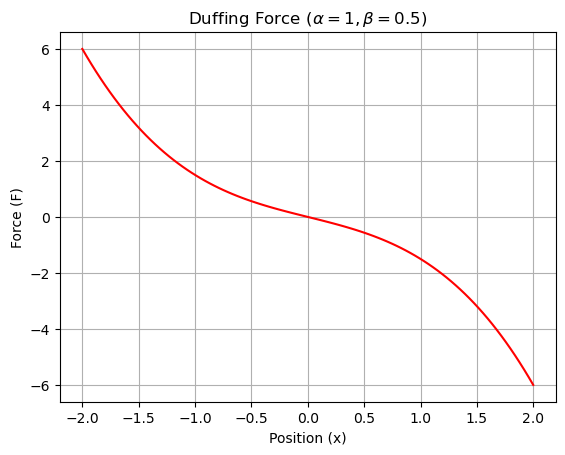

In [5]:
import sympy as sp

x, alpha, beta = sp.symbols('x alpha beta')
V = 0.5 * alpha * x**2 + 0.25 * beta * x**4
force_expr = -sp.diff(V, x)
print(f"Symbolic Force: {force_expr}")

# Substituting constants and plotting
alpha_val, beta_val = 1, 0.5
f_numeric = sp.lambdify(x, force_expr.subs({alpha: alpha_val, beta: beta_val}), 'numpy')

x_range = np.linspace(-2, 2, 100)
plt.figure()
plt.plot(x_range, f_numeric(x_range), 'r')
plt.title(f"Duffing Force ($\\alpha={alpha_val}, \\beta={beta_val}$)")
plt.xlabel("Position (x)")
plt.ylabel("Force (F)")
plt.grid(True)
plt.show()

## 4. SymPy: Solving the Damped Oscillator

I defined $x(t)$ as a function and built the second-order ODE. After substituting $\gamma=5$ and $\omega_0=2$, I solved for the overdamped case. The result contains exponentials. This is because the system is so heavily damped that it "oozes" back to equilibrium without ever oscillating (no sines or cosines).

In [6]:
t, gamma, w0 = sp.symbols('t gamma omega_0')
x_func = sp.Function('x')(t)
# ODE: x'' + gamma*x' + w0^2*x = 0
ode = sp.Eq(x_func.diff(t, t) + gamma * x_func.diff(t) + w0**2 * x_func, 0)

# General Solution
gen_sol = sp.dsolve(ode, x_func)

# Overdamped Case
overdamped_sol = gen_sol.subs({gamma: 5, w0: 2})
print("Overdamped Solution:")
sp.pprint(overdamped_sol)

Overdamped Solution:
           -t       -4⋅t
x(t) = C₁⋅ℯ   + C₂⋅ℯ    


## 5. Quantum: The Finite Square Well

The transcendental equation for even states is $\sqrt{E} \tan\left(\sqrt{\frac{2mL^2E}{\hbar^2}}\right) = \sqrt{V_0 - E}$. I defined the root function $f(E) = LHS - RHS$. By plotting this, I can see where it crosses zero. The first crossing point represents the ground state energy. Using a root-finding algorithm, I found the exact value.

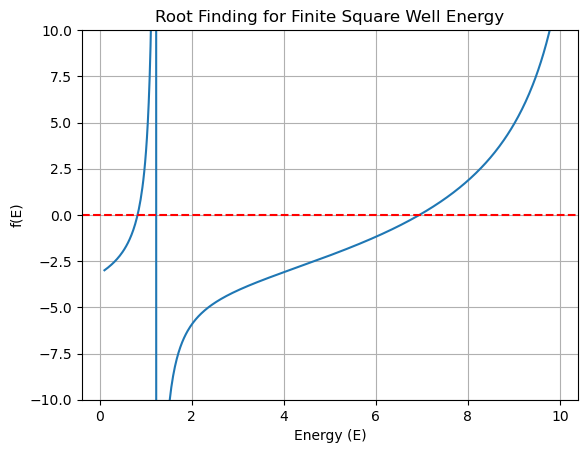

Calculated Ground State Energy E: 0.81974


In [7]:
from scipy.optimize import root_scalar

# Constants for calculation (m=1, L=1, hbar=1, V0=10)
m_val, L_val, hbar_val, V0_val = 1, 1, 1, 10

def f_root(E):
    lhs = np.sqrt(E) * np.tan(np.sqrt(2 * m_val * L_val**2 * E / hbar_val**2))
    rhs = np.sqrt(V0_val - E)
    return lhs - rhs

# Visualization
E_vals = np.linspace(0.1, 9.9, 500)
plt.figure()
plt.plot(E_vals, f_root(E_vals))
plt.axhline(0, color='red', linestyle='--')
plt.ylim(-10, 10)
plt.title("Root Finding for Finite Square Well Energy")
plt.xlabel("Energy (E)")
plt.ylabel("f(E)")
plt.grid(True)
plt.show()

# Exact Ground State Energy
# Looking at the plot, the root is between 0.1 and 1.2 (before the first asymptote)
result = root_scalar(f_root, bracket=[0.1, 1.2])
print(f"Calculated Ground State Energy E: {result.root:.5f}")